In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("KAG_conversion_data.csv")

In [4]:
df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


In [5]:
df.tail()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
1138,1314410,1178,179977,45-49,F,109,1129773,252,358.189997,13,2
1139,1314411,1178,179978,45-49,F,110,637549,120,173.880003,3,0
1140,1314412,1178,179979,45-49,F,111,151531,28,40.289999,2,0
1141,1314414,1178,179981,45-49,F,113,790253,135,198.710001,8,2
1142,1314415,1178,179982,45-49,F,114,513161,114,165.609999,5,2


In [6]:
df.shape

(1143, 11)

In [7]:
df.columns

Index(['ad_id', 'xyz_campaign_id', 'fb_campaign_id', 'age', 'gender',
       'interest', 'Impressions', 'Clicks', 'Spent', 'Total_Conversion',
       'Approved_Conversion'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   str    
 4   gender               1143 non-null   str    
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   int64  
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   int64  
 10  Approved_Conversion  1143 non-null   int64  
dtypes: float64(1), int64(8), str(2)
memory usage: 105.1 KB


In [9]:
df.describe()

,ad_id,xyz_campaign_id,fb_campaign_id,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
count,1.143000e+03,1143.000000,1143.000000,1143.000000,1.143000e+03,1143.000000,1143.000000,1143.000000,1143.000000
mean,9.872611e+05,1067.382327,133783.989501,32.766404,1.867321e+05,33.390201,51.360656,2.855643,0.944007
std,1.939928e+05,121.629393,20500.308622,26.952131,3.127622e+05,56.892438,86.908418,4.483593,1.737708
min,7.087460e+05,916.000000,103916.000000,2.000000,8.700000e+01,0.000000,0.000000,0.000000,0.000000
25%,7.776325e+05,936.000000,115716.000000,16.000000,6.503500e+03,1.000000,1.480000,1.000000,0.000000
50%,1.121185e+06,1178.000000,144549.000000,25.000000,5.150900e+04,8.000000,12.370000,1.000000,1.000000
75%,1.121804e+06,1178.000000,144657.500000,31.000000,2.217690e+05,37.500000,60.025000,3.000000,1.000000
max,1.314415e+06,1178.000000,179982.000000,114.000000,3.052003e+06,421.000000,639.949998,60.000000,21.000000


In [10]:
df.isnull().sum()

ad_id                  0
xyz_campaign_id        0
fb_campaign_id         0
age                    0
gender                 0
interest               0
Impressions            0
Clicks                 0
Spent                  0
Total_Conversion       0
Approved_Conversion    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(1143, 11)

In [14]:
df.dtypes

ad_id                    int64
xyz_campaign_id          int64
fb_campaign_id           int64
age                        str
gender                     str
interest                 int64
Impressions              int64
Clicks                   int64
Spent                  float64
Total_Conversion         int64
Approved_Conversion      int64
dtype: object

In [15]:
df['CTR'] = (df['Clicks'] / df['Impressions']) * 100
df['Conversion_Rate'] = (df['Total_Conversion'] / df['Clicks']) * 100

In [16]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,CTR,Conversion_Rate
0,708746,916,103916,30-34,M,15,7350,1,1.430000,2,1,0.013605,200.000000
1,708749,916,103917,30-34,M,16,17861,2,1.820000,2,0,0.011198,100.000000
2,708771,916,103920,30-34,M,20,693,0,0.000000,1,0,0.000000,NaN
3,708815,916,103928,30-34,M,28,4259,1,1.250000,1,0,0.023480,100.000000
4,708818,916,103928,30-34,M,28,4133,1,1.290000,1,1,0.024195,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,1314410,1178,179977,45-49,F,109,1129773,252,358.189997,13,2,0.022305,5.158730
1139,1314411,1178,179978,45-49,F,110,637549,120,173.880003,3,0,0.018822,2.500000
1140,1314412,1178,179979,45-49,F,111,151531,28,40.289999,2,0,0.018478,7.142857
1141,1314414,1178,179981,45-49,F,113,790253,135,198.710001,8,2,0.017083,5.925926


In [17]:
df.fillna(0, inplace=True)

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,CTR,Conversion_Rate
0,708746,916,103916,30-34,M,15,7350,1,1.430000,2,1,0.013605,200.000000
1,708749,916,103917,30-34,M,16,17861,2,1.820000,2,0,0.011198,100.000000
2,708771,916,103920,30-34,M,20,693,0,0.000000,1,0,0.000000,0.000000
3,708815,916,103928,30-34,M,28,4259,1,1.250000,1,0,0.023480,100.000000
4,708818,916,103928,30-34,M,28,4133,1,1.290000,1,1,0.024195,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,1314410,1178,179977,45-49,F,109,1129773,252,358.189997,13,2,0.022305,5.158730
1139,1314411,1178,179978,45-49,F,110,637549,120,173.880003,3,0,0.018822,2.500000
1140,1314412,1178,179979,45-49,F,111,151531,28,40.289999,2,0,0.018478,7.142857
1141,1314414,1178,179981,45-49,F,113,790253,135,198.710001,8,2,0.017083,5.925926


In [18]:
df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,CTR,Conversion_Rate
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1,0.013605,200.0
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0,0.011198,100.0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0,0.000000,0.0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0,0.023480,100.0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1,0.024195,100.0


In [19]:
df = pd.get_dummies(df, columns=['age', 'gender'], drop_first=True)

In [20]:
df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,CTR,Conversion_Rate,age_35-39,age_40-44,age_45-49,gender_M
0,708746,916,103916,15,7350,1,1.43,2,1,0.013605,200.0,False,False,False,True
1,708749,916,103917,16,17861,2,1.82,2,0,0.011198,100.0,False,False,False,True
2,708771,916,103920,20,693,0,0.00,1,0,0.000000,0.0,False,False,False,True
3,708815,916,103928,28,4259,1,1.25,1,0,0.023480,100.0,False,False,False,True
4,708818,916,103928,28,4133,1,1.29,1,1,0.024195,100.0,False,False,False,True


In [21]:
X = df.drop("Approved_Conversion", axis=1)
y = df["Approved_Conversion"]

In [22]:
print(X.head())
print(y.head())

    ad_id  xyz_campaign_id  fb_campaign_id  interest  Impressions  Clicks  \
0  708746              916          103916        15         7350       1   
1  708749              916          103917        16        17861       2   
2  708771              916          103920        20          693       0   
3  708815              916          103928        28         4259       1   
4  708818              916          103928        28         4133       1   

   Spent  Total_Conversion       CTR  Conversion_Rate  age_35-39  age_40-44  \
0   1.43                 2  0.013605            200.0      False      False   
1   1.82                 2  0.011198            100.0      False      False   
2   0.00                 1  0.000000              0.0      False      False   
3   1.25                 1  0.023480            100.0      False      False   
4   1.29                 1  0.024195            100.0      False      False   

   age_45-49  gender_M  
0      False      True  
1      False

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (914, 14)
X_test shape: (229, 14)
y_train shape: (914,)
y_test shape: (229,)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

In [27]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [29]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()

knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

In [30]:
from sklearn.svm import SVR

svr = SVR()

svr.fit(X_train_scaled, y_train)

pred_svr = svr.predict(X_test_scaled)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, pred):
    print("MAE :", mean_absolute_error(y_true, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, pred)))
    print("R² Score:", r2_score(y_true, pred))

In [32]:
print("Linear Regression")
evaluate(y_test, pred_lr)

print("\nDecision Tree")
evaluate(y_test, pred_dt)

print("\nRandom Forest")
evaluate(y_test, pred_rf)

print("\nKNN")
evaluate(y_test, pred_knn)

print("\nSVR")
evaluate(y_test, pred_svr)

Linear Regression
MAE : 0.625374122204402
RMSE: 0.8883371555109948
R² Score: 0.7596054388287297

Decision Tree
MAE : 0.7117903930131004
RMSE: 1.1986163784578547
R² Score: 0.5623475149290147

Random Forest
MAE : 0.6540174672489082
RMSE: 1.0056558397992184
R² Score: 0.6919169940981016

KNN
MAE : 0.714410480349345
RMSE: 1.1536916255274747
R² Score: 0.5945395822199504

SVR
MAE : 0.6555226556638483
RMSE: 1.3940525694353212
R² Score: 0.4079923951372104


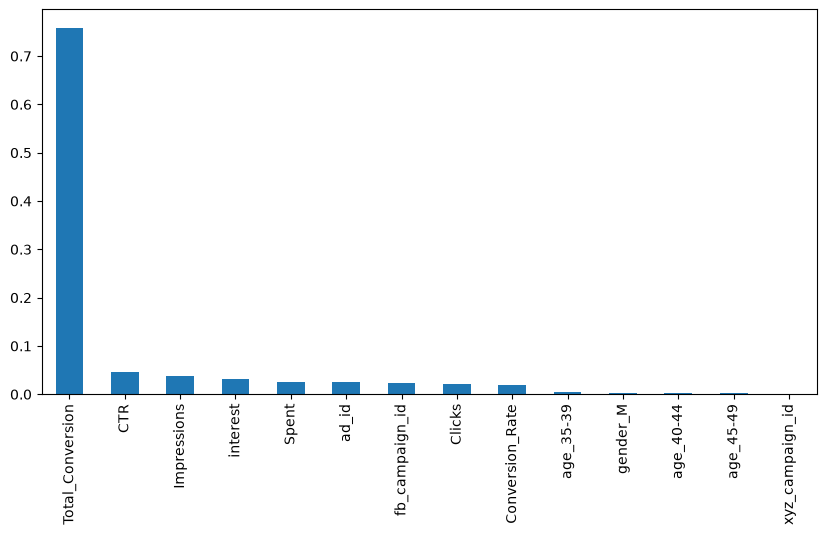

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))

plt.show()

In [35]:
import pickle
import os

model_path =  "advertisement_model.pkl"

with open(model_path, "rb") as file:
    model = pickle.load(file)

In [36]:
pickle.dump(scaler, open("scaler.pkl", "wb"))